Practical 7 — Random Forests, OOB Error, Bagging and Feature Subsampling
Iris Dataset
Aim

Implement and analyse Random Forests using training and validation data, study OOB error convergence, compare max_features, demonstrate manual bootstrap bagging, calculate permutation importance, and compare a Random Forest with a single Decision Tree.

In [7]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
# ============================================================
# 2. LOAD IRIS DATASET
# ============================================================

iris = datasets.load_iris()

X = iris.data
y = iris.target

print("Iris dataset loaded successfully.")
print("Shape:", X.shape)

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

Iris dataset loaded successfully.
Shape: (150, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [11]:
# ============================================================
# 3. DISPLAY DATASET
# ============================================================

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [12]:
# ============================================================
# 4. DATA PREPROCESSING
# ============================================================

data_model = df.copy()

print("Preprocessed dataset:")
display(data_model)

print("\nData types:")
print(data_model.dtypes)

print("\nMissing values:")
print(data_model.isnull().sum())

Preprocessed dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2



Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [13]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["target"])
y = data_model["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: target")

print("\nX:")
display(X.head())

print("\ny:")
display(y.head())

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target: target

X:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



y:


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Step 1 — Training Data and Validation Data

The original P7 uses a 70–30 split and stratify=y. We'll keep that structure.


In [14]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training samples: 105
Validation samples: 45

Training class distribution:
target
1    35
0    35
2    35
Name: count, dtype: int64

Validation class distribution:
target
2    15
1    15
0    15
Name: count, dtype: int64


Part A — Single Decision Tree Baseline

The original P7 first creates one Decision Tree as the baseline

In [15]:
# ============================================================
# 7. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)

print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")

SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
Tree Depth          : 6
Number of Leaves    : 8


# Part B — Random Forest

A Random Forest creates many Decision Trees.

Important parameters:

- `n_estimators` → number of trees.
- `bootstrap=True` → each tree gets a bootstrap sample.
- `oob_score=True` → calculate Out-of-Bag accuracy.
- `max_features` → random feature subsampling at each split.


In [16]:
# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)

print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")

RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
OOB Accuracy        : 0.9524
OOB Error           : 0.0476


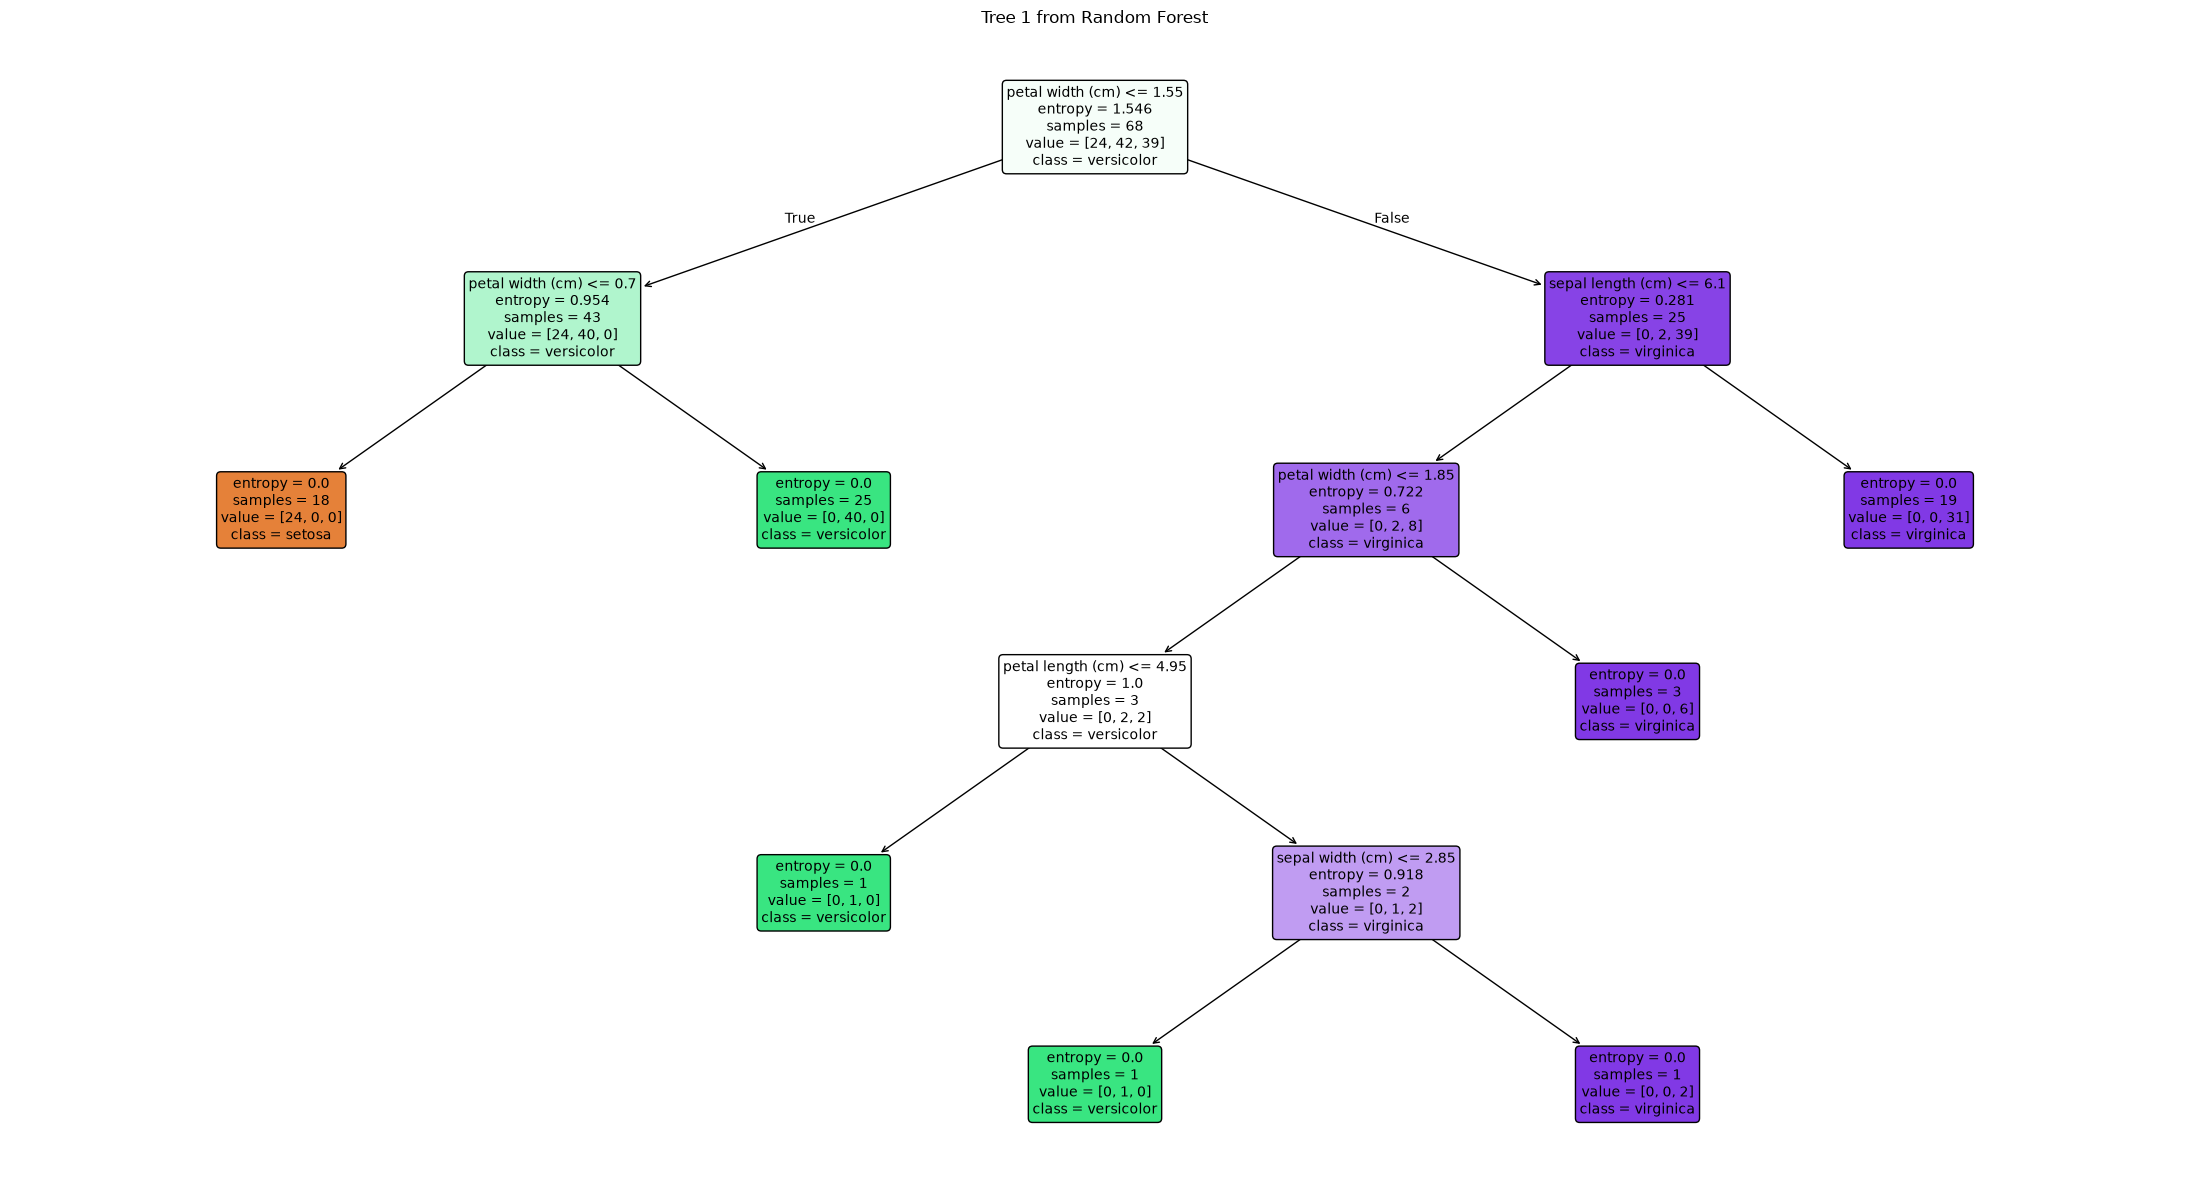

In [17]:
# ============================================================
# 9. DISPLAY TREE 1 FROM RANDOM FOREST
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 1 from Random Forest")
plt.tight_layout()
plt.show()

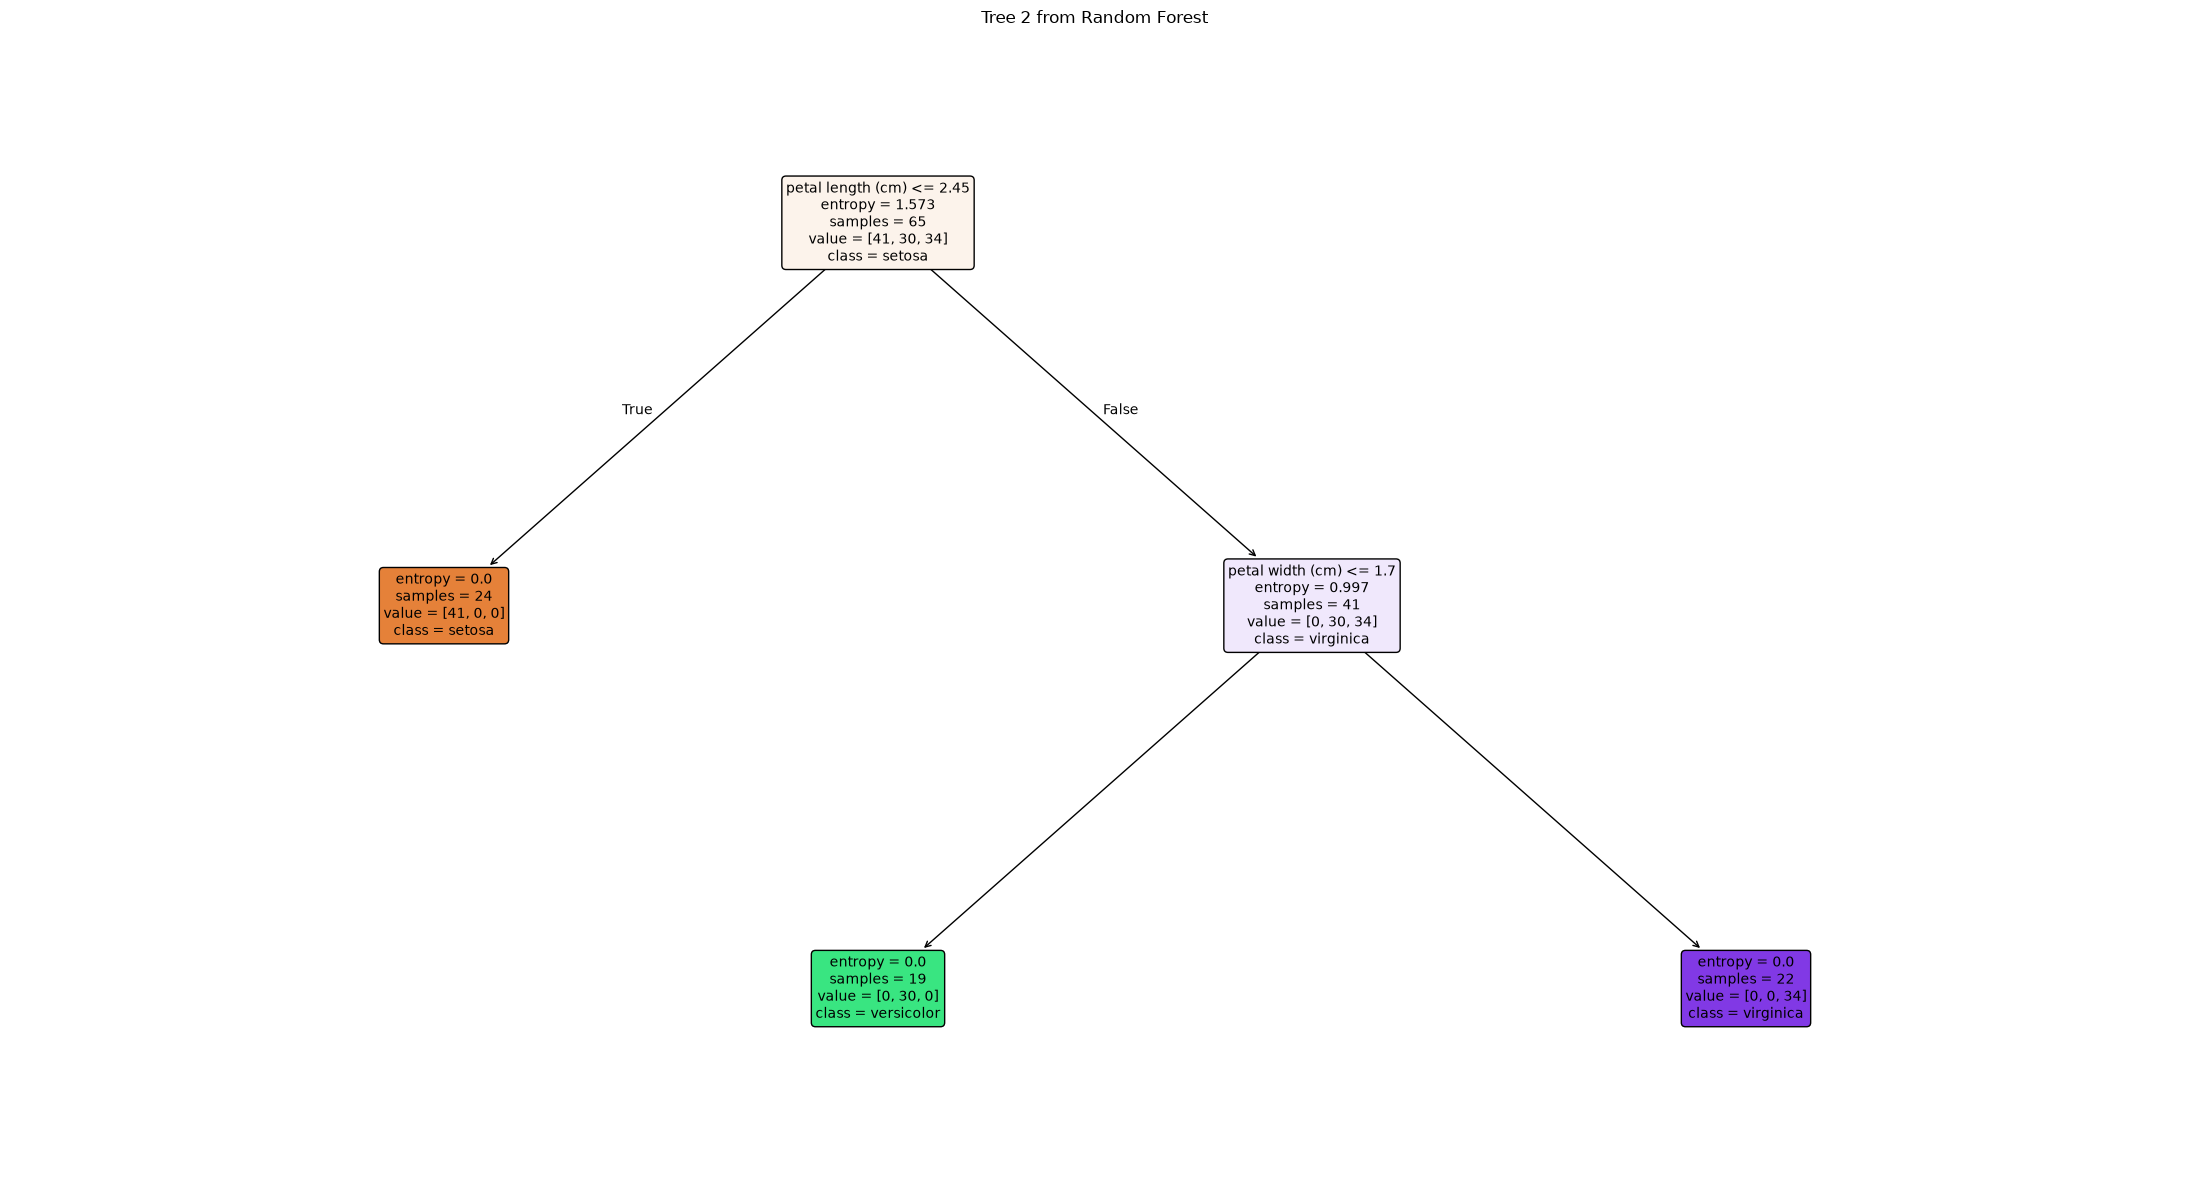

In [18]:
# ============================================================
# 10. DISPLAY TREE 2 FROM RANDOM FOREST
# ============================================================

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[1],
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 2 from Random Forest")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 11. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=iris.target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



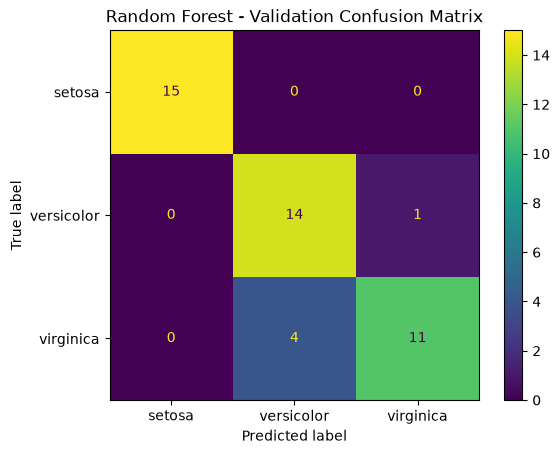

In [20]:
# ============================================================
# 12. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_val,
    rf_val_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

Part C — OOB Error Convergence

The original P7 checks how OOB error changes as the number of trees increases.

In [21]:
# ============================================================
# 13. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [
    1, 5, 10, 20, 30, 50, 75, 100, 150, 200
]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))

c:\Users\tallu\Downloads\ML\Placement Prediction System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\tallu\Downloads\ML\Placement Prediction System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.5143,0.4857
1,5,0.8857,0.1143
2,10,0.9714,0.0286
3,20,0.9619,0.0381
4,30,0.9619,0.0381
5,50,0.9524,0.0476
6,75,0.9524,0.0476
7,100,0.9524,0.0476
8,150,0.9524,0.0476
9,200,0.9524,0.0476


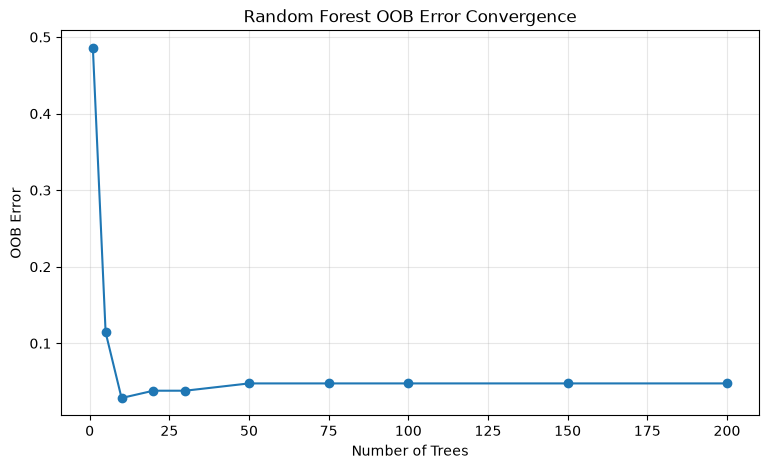

In [22]:
# ============================================================
# 14. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")

plt.grid(True, alpha=0.3)
plt.show()

Part D — max_features Comparison

In [23]:
# ============================================================
# 15. COMPARE max_features
# ============================================================

max_features_values = [
    "sqrt",
    "log2",
    None
]

max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "Validation_Accuracy": accuracy_score(
            y_val,
            val_pred
        ),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(
    max_features_results
)

display(max_features_df.round(4))

,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.8889,0.9524,0.0476
1,log2,1.0,0.8889,0.9524,0.0476
2,None,1.0,0.9333,0.9524,0.0476


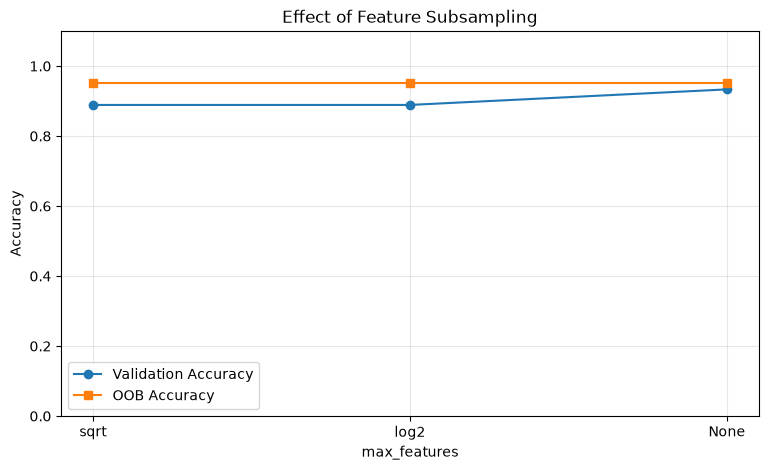

In [24]:
# ============================================================
# 16. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")

plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

plt.show()

Part E — Manual Bootstrap Bagging

The original practical manually creates bootstrap samples before using BaggingClassifier.

In [25]:
# ============================================================
# 17. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))

Bootstrap indices:
[  9  81  68  46  45  90   9  73  21   9  55 102  77  79  75  82  53  13
  88  47  52  38  19  97  82  67  42  86  57  46  47  23   9  58  93   6
  90  86  29  66  17  79  73  37   7 101  46  93  71  81  79  20  38  49
  52   4  57  16  78  71  96  78  38 101  43  34  95  38   8  49  83  19
  48  13  72  49  34  23  59  70  98  45  16  87  66  73  10  32  80  87
  45  84  88  40  94  30  25  71  66  14  87  20  84   0  83]

Unique selected rows:
[  0   4   6   7   8   9  10  13  14  16  17  19  20  21  23  25  29  30
  32  34  37  38  40  42  43  45  46  47  48  49  52  53  55  57  58  59
  66  67  68  70  71  72  73  75  77  78  79  80  81  82  83  84  86  87
  88  90  93  94  95  96  97  98 101 102]

OOB row indices:
[  1   2   3   5  11  12  15  18  22  24  26  27  28  31  33  35  36  39
  41  44  50  51  54  56  60  61  62  63  64  65  69  74  76  85  89  91
  92  99 100 103 104]

Total bootstrap observations: 105
Unique observations: 64
OOB observations: 41


# Part F — scikit-learn BaggingClassifier

The previous cells showed the mechanism manually.

Now `BaggingClassifier` automates bootstrap sampling and combines the tree predictions.

**Bagging vs Random Forest:**
- Bagging mainly uses bootstrap samples.
- Random Forest additionally introduces random feature selection at splits.


In [26]:
# ============================================================
# 18. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []

rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)

    manual_trees.append(tree)

print(
    f"{N_MANUAL_TREES} manually bagged trees trained."
)

50 manually bagged trees trained.


In [27]:
# ============================================================
# 19. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

manual_bagging_pred = (
    np.mean(
        tree_predictions,
        axis=0
    ) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)

Manual Bootstrap Bagging Validation Accuracy: 0.6667


In [28]:
# ============================================================
# 20. BAGGING CLASSIFIER
# ============================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)

print(
    f"Training Accuracy   : "
    f"{accuracy_score(y_train, bagging_train_pred):.4f}"
)

print(
    f"Validation Accuracy : "
    f"{accuracy_score(y_val, bagging_val_pred):.4f}"
)

BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.9556


Part G — Permutation Importance

The original P7 uses permutation importance on the validation set

In [29]:
# ============================================================
# 21. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(
    importance_df.round(4)
)

,Feature,Mean_Importance,Std_Importance
0,petal length (cm),0.1607,0.0400
1,petal width (cm),0.1370,0.0340
2,sepal width (cm),-0.0030,0.0076
3,sepal length (cm),-0.0185,0.0142


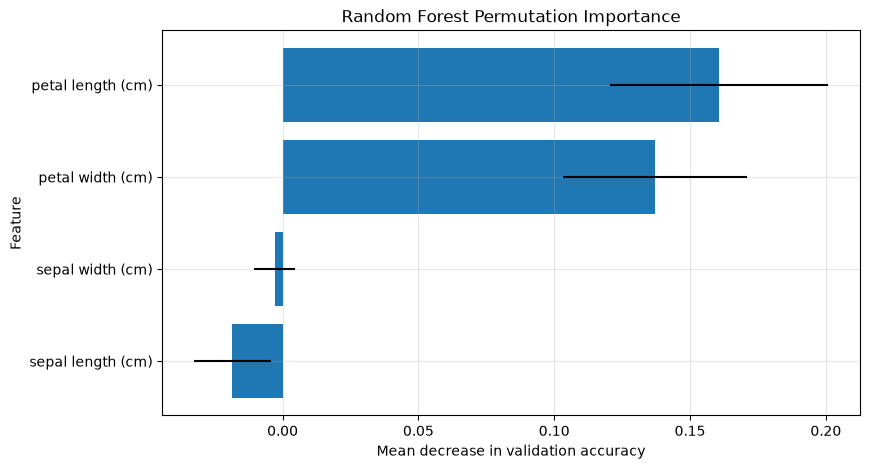

In [30]:
# ============================================================
# 22. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel(
    "Mean decrease in validation accuracy"
)

plt.ylabel("Feature")

plt.title(
    "Random Forest Permutation Importance"
)

plt.gca().invert_yaxis()

plt.grid(True, alpha=0.3)

plt.show()

Part H — rf_vs_single_tree() Function

This keeps the main reusable experiment from P7.

In [31]:
# ============================================================
# 23. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):

    """
    Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame containing:
        n_estimators
        RF_val_acc
        DT_val_acc
        OOB_acc
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------

    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------

    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------

    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel(
        "Number of Trees (n_estimators)"
    )

    plt.ylabel("Accuracy")

    plt.title(
        "Random Forest vs Single Decision Tree"
    )

    plt.legend()

    plt.ylim(0, 1.1)

    plt.grid(True, alpha=0.3)

    plt.show()

    return results_df

c:\Users\tallu\Downloads\ML\Placement Prediction System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\tallu\Downloads\ML\Placement Prediction System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


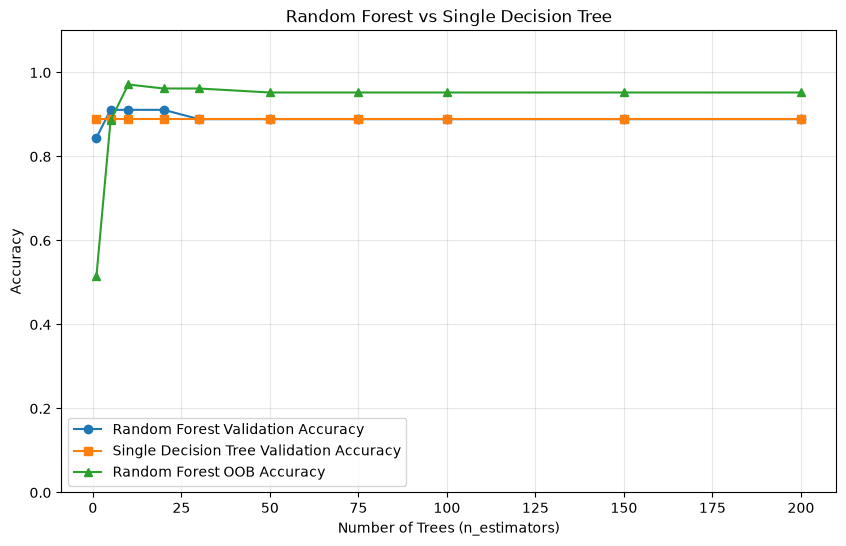

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.8444,0.8889,0.5143
1,5,0.9111,0.8889,0.8857
2,10,0.9111,0.8889,0.9714
3,20,0.9111,0.8889,0.9619
4,30,0.8889,0.8889,0.9619
5,50,0.8889,0.8889,0.9524
6,75,0.8889,0.8889,0.9524
7,100,0.8889,0.8889,0.9524
8,150,0.8889,0.8889,0.9524
9,200,0.8889,0.8889,0.9524


In [32]:
# ============================================================
# 24. RUN THE FUNCTION
# ============================================================

n_estimators_list = [
    1, 5, 10, 20, 30, 50, 75, 100, 150, 200
]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(
    rf_dt_results.round(4)
)

In [33]:
# ============================================================
# 25. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print(
    "Best Random Forest result based on validation accuracy:"
)

print("=" * 65)

print(
    best_rf_row.to_string()
)

Best Random Forest result based on validation accuracy:
n_estimators    5.000000
RF_val_acc      0.911111
DT_val_acc      0.888889
OOB_acc         0.885714


In [34]:
# ============================================================
# 26. OVERALL COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({

    "Model": [
        "Single Decision Tree",
        "Random Forest",
        "Manual Bootstrap Bagging",
        "BaggingClassifier"
    ],

    "Training Accuracy": [

        accuracy_score(
            y_train,
            dt_train_pred
        ),

        accuracy_score(
            y_train,
            rf_train_pred
        ),

        np.nan,

        accuracy_score(
            y_train,
            bagging_train_pred
        )
    ],

    "Validation Accuracy": [

        accuracy_score(
            y_val,
            dt_val_pred
        ),

        accuracy_score(
            y_val,
            rf_val_pred
        ),

        manual_bagging_acc,

        accuracy_score(
            y_val,
            bagging_val_pred
        )
    ],

    "OOB Accuracy": [

        np.nan,

        rf.oob_score_,

        np.nan,

        np.nan
    ]
})

display(
    overall_comparison.round(4)
)

,Model,Training Accuracy,Validation Accuracy,OOB Accuracy
0,Single Decision Tree,1.0,0.8889,NaN
1,Random Forest,1.0,0.8889,0.9524
2,Manual Bootstrap Bagging,NaN,0.6667,NaN
3,BaggingClassifier,1.0,0.9556,NaN


In [35]:
# ============================================================
# FINAL LEARNING SUMMARY
# ============================================================

print("FINAL LEARNING SUMMARY")
print("=" * 60)

print("""
1. Random Forest combines many Decision Trees.

2. Bootstrap sampling creates different training sets.

3. OOB observations are samples not selected in a
   particular tree's bootstrap sample.

4. OOB error can be studied as the number of trees increases.

5. max_features controls how many features are considered
   when searching for a split.

6. Feature subsampling makes individual trees different.

7. Manual bagging demonstrates bootstrap sampling and
   majority voting.

8. Permutation importance identifies influential features.

9. Random Forest can be compared with a single Decision Tree
   using validation accuracy.

10. Iris is a small, standard teaching dataset, so the results
    are primarily useful for understanding the algorithms.
""")

FINAL LEARNING SUMMARY

1. Random Forest combines many Decision Trees.

2. Bootstrap sampling creates different training sets.

3. OOB observations are samples not selected in a
   particular tree's bootstrap sample.

4. OOB error can be studied as the number of trees increases.

5. max_features controls how many features are considered
   when searching for a split.

6. Feature subsampling makes individual trees different.

7. Manual bagging demonstrates bootstrap sampling and
   majority voting.

8. Permutation importance identifies influential features.

9. Random Forest can be compared with a single Decision Tree
   using validation accuracy.

10. Iris is a small, standard teaching dataset, so the results
    are primarily useful for understanding the algorithms.

